In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
df=pd.read_csv("diabetes.csv")

In [40]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [41]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [42]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


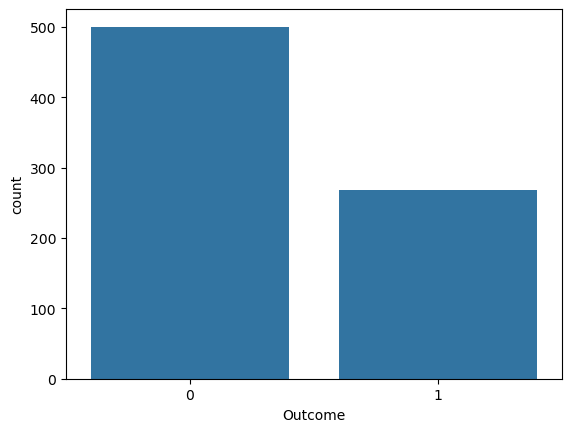

In [44]:
df['Outcome'].value_counts()
sns.countplot(x='Outcome', data=df)
plt.show()

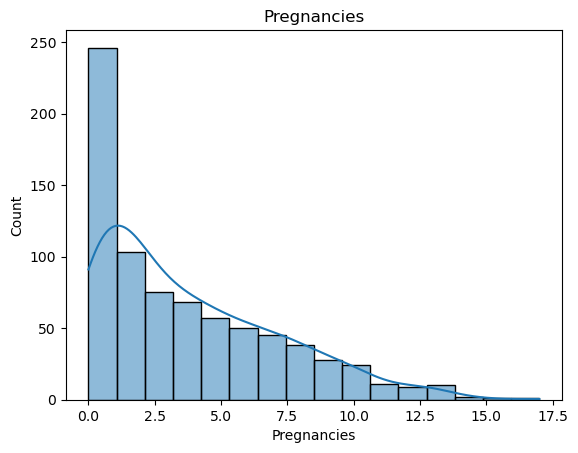

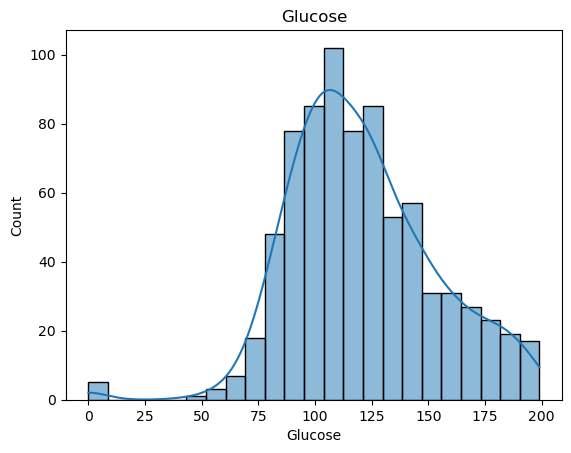

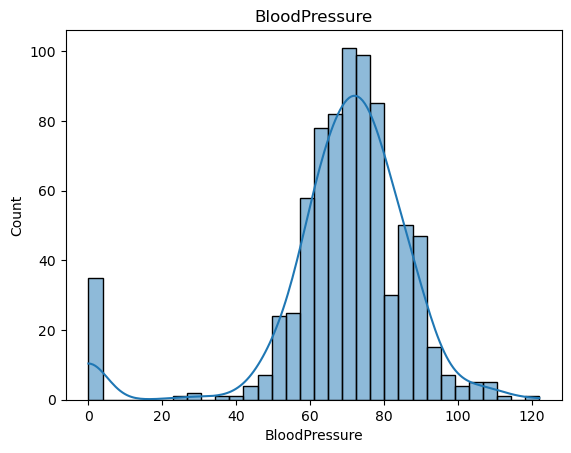

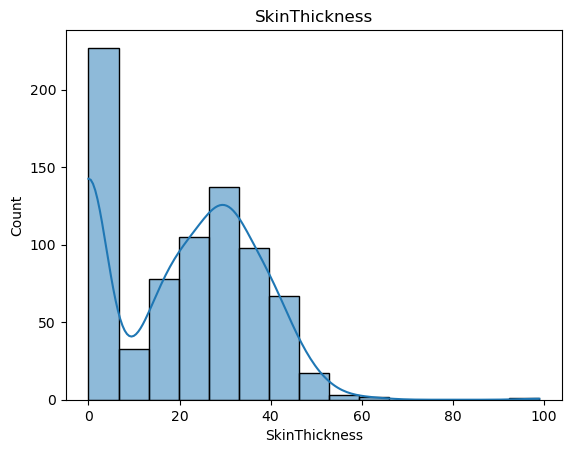

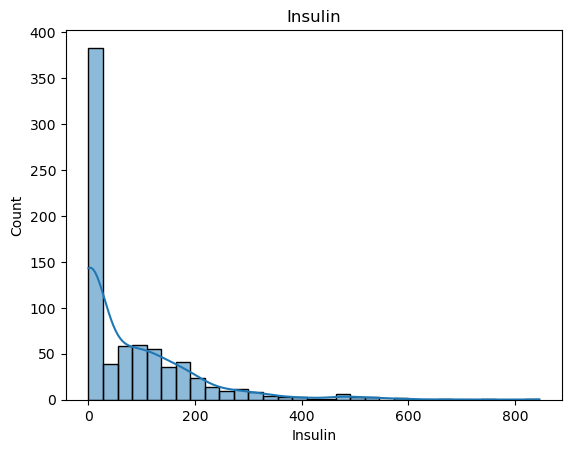

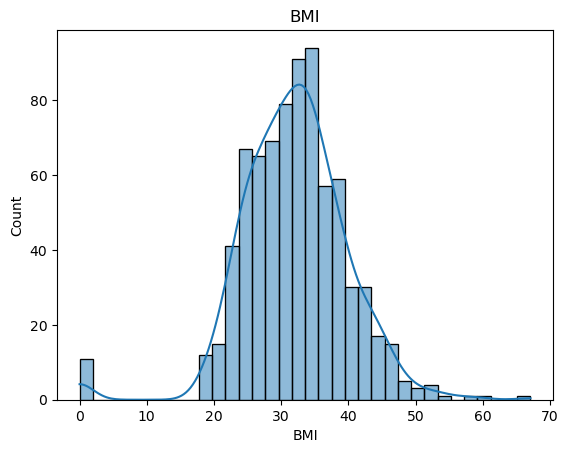

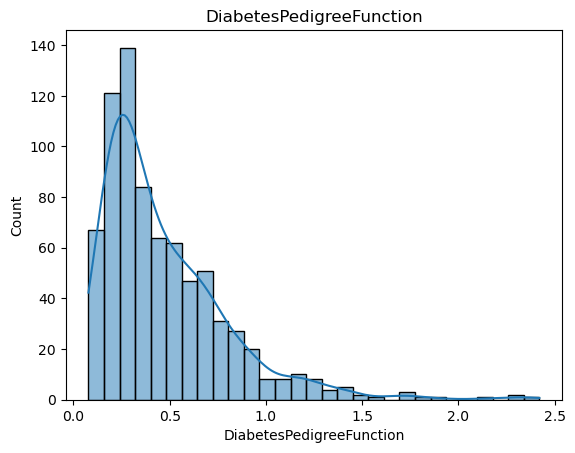

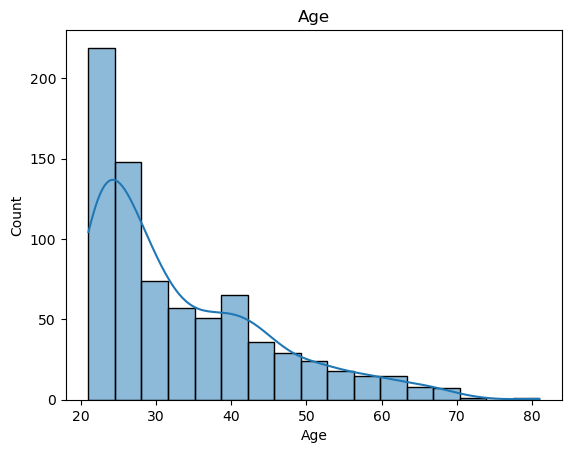

In [45]:
for col in df.columns[:-1]:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

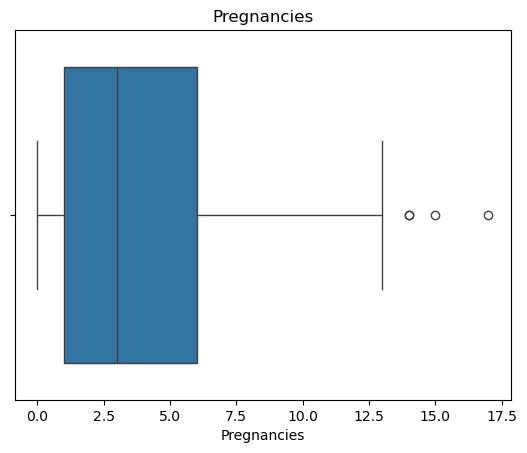

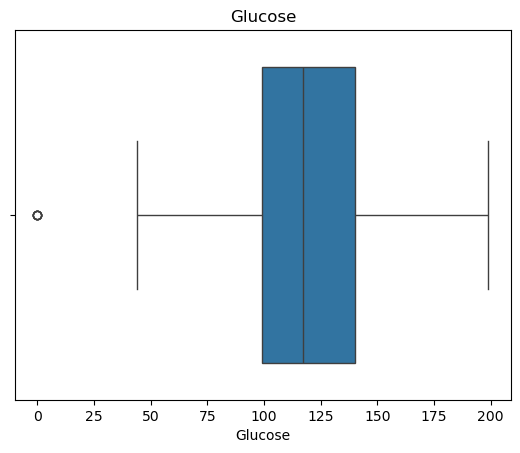

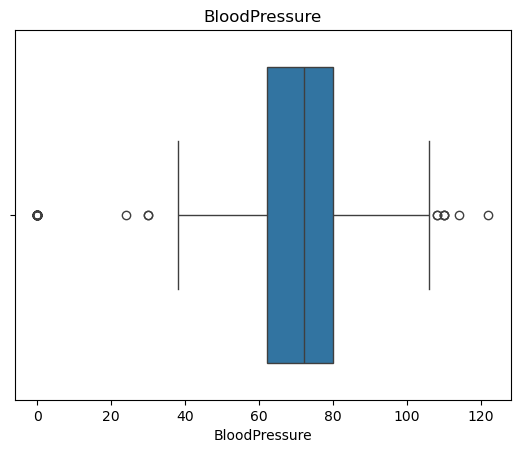

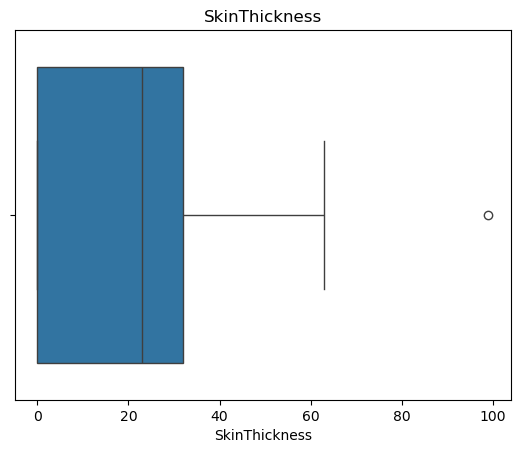

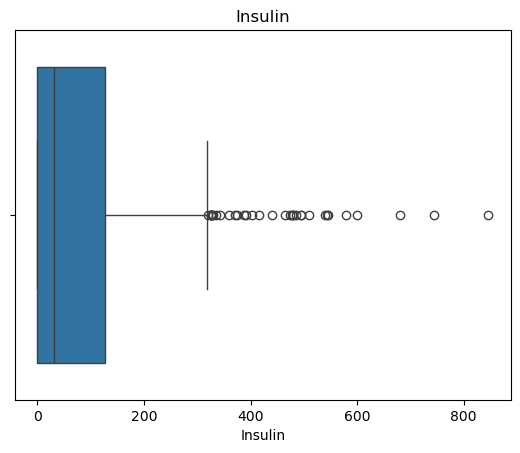

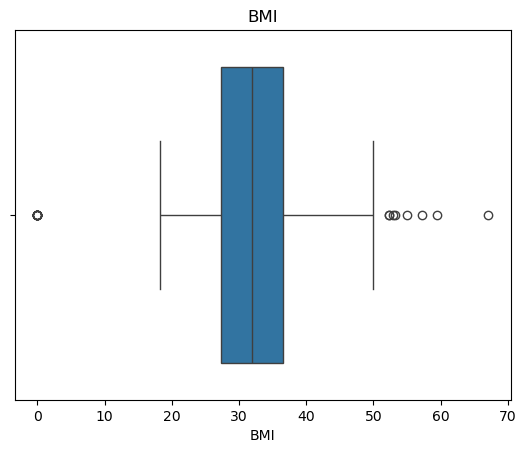

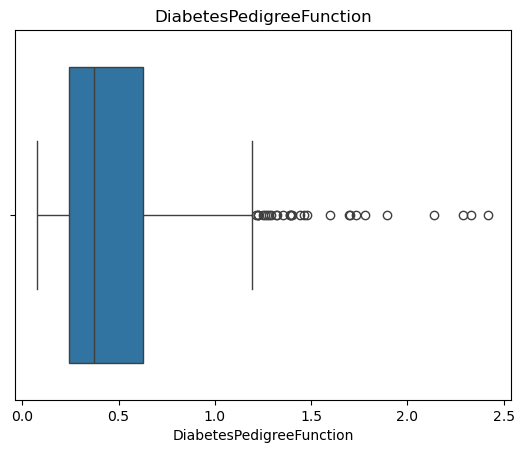

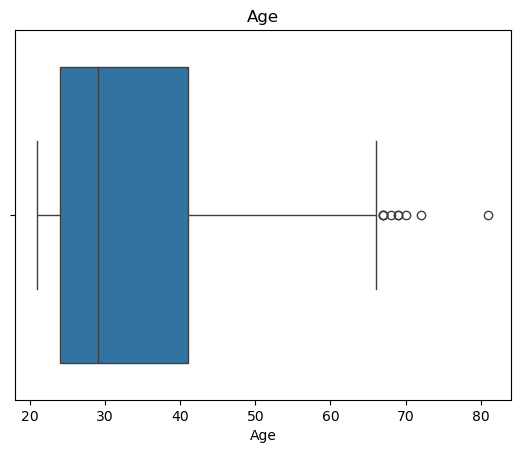

In [46]:
for col in df.columns[:-1]:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [60]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['Age'] >= lower) &
        (df['Age'] <= upper)]

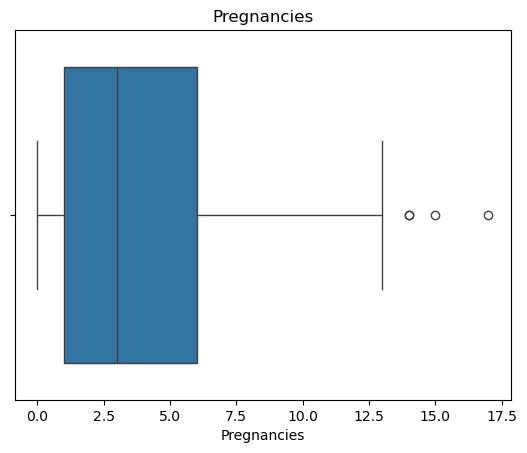

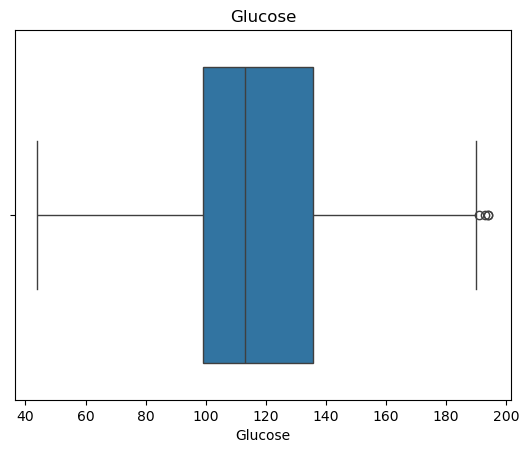

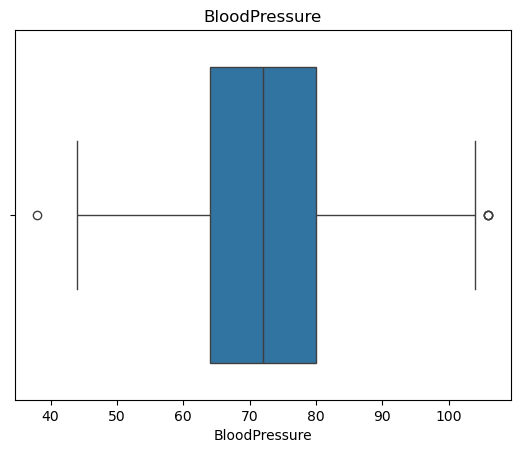

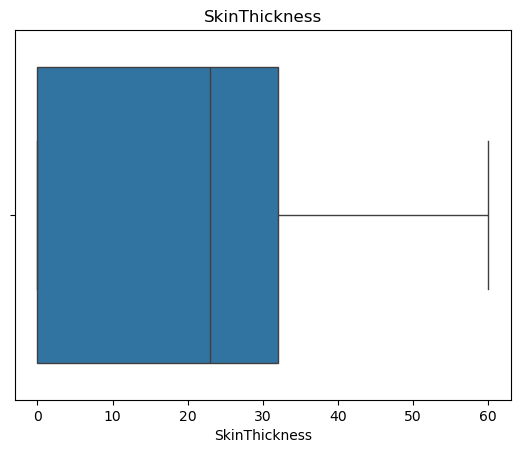

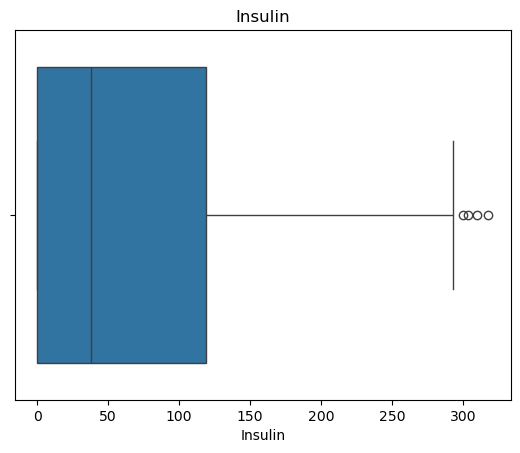

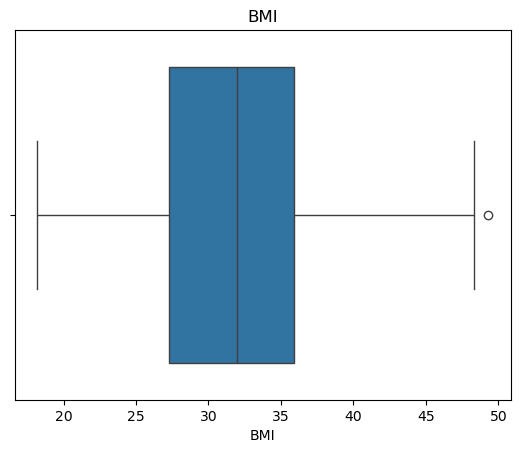

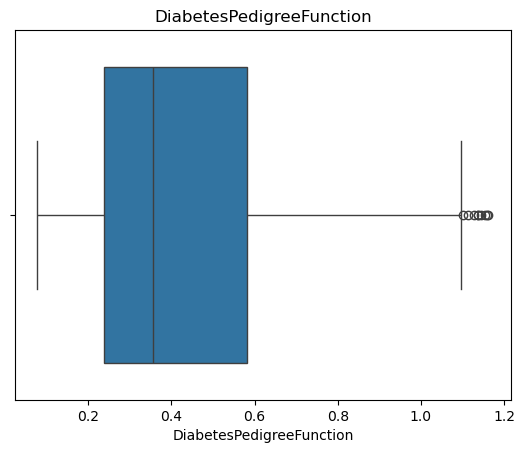

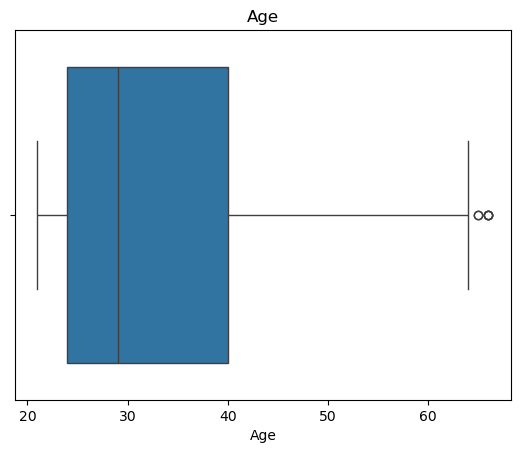

In [61]:
for col in df.columns[:-1]:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [62]:
cols = ['Glucose','BloodPressure',
        'SkinThickness','Insulin','BMI']

for col in cols:
    print(col,(df[col]==0).sum())

Glucose 0
BloodPressure 0
SkinThickness 175
Insulin 302
BMI 0


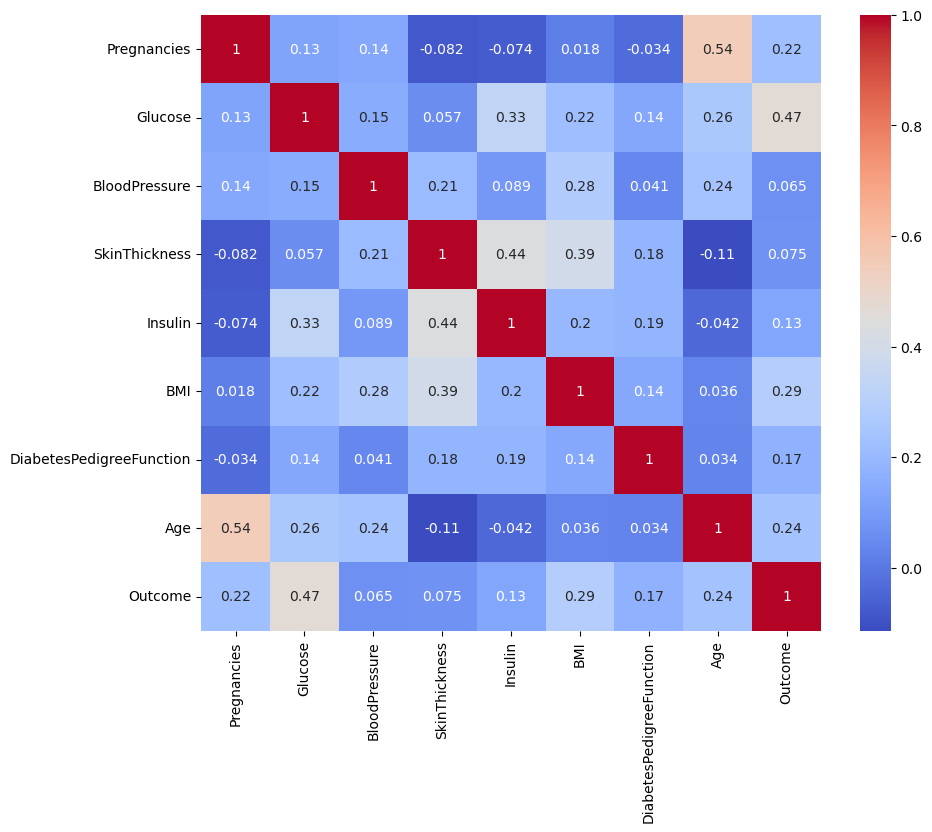

In [19]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')
plt.show()

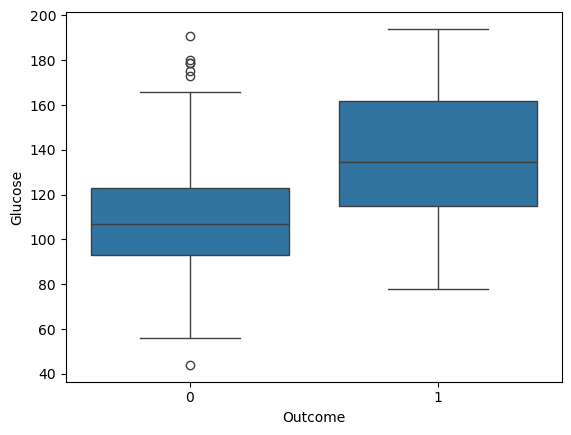

In [63]:
sns.boxplot(
    x='Outcome',
    y='Glucose',
    data=df
)
plt.show()

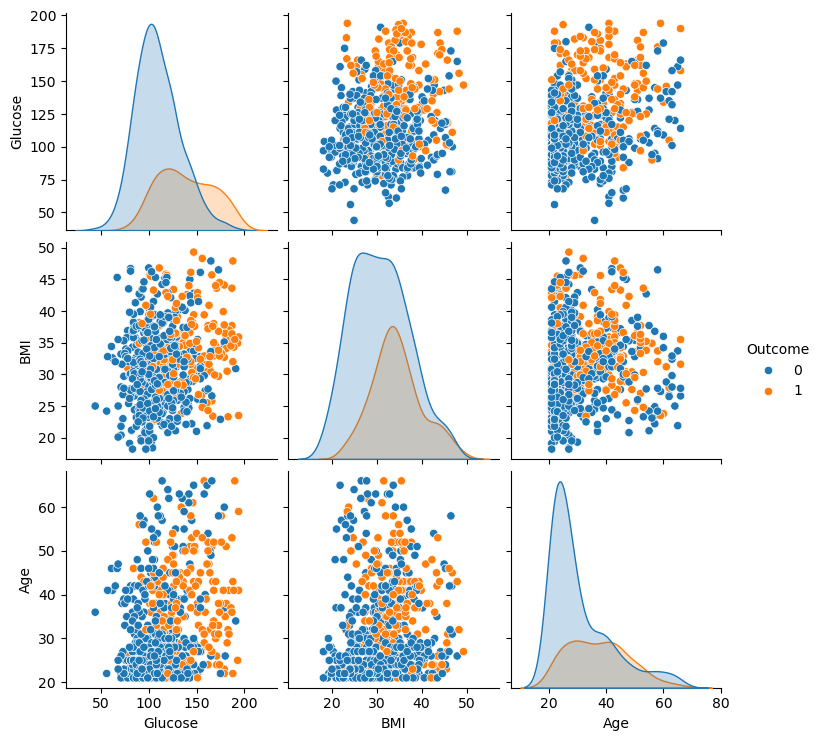

In [64]:
sns.pairplot(
    df[['Glucose',
        'BMI',
        'Age',
        'Outcome']],
    hue='Outcome'
)
plt.show()

In [72]:
cols = ['Glucose','BloodPressure',
        'SkinThickness','Insulin','BMI']

for col in cols:
    df[col] = df[col].replace(0, df[col].median())

In [73]:
cols = ['Glucose','BloodPressure',
        'SkinThickness','Insulin','BMI']

for col in cols:
    print(col,(df[col]==0).sum())

Glucose 0
BloodPressure 0
SkinThickness 0
Insulin 0
BMI 0


In [75]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X = df.drop('Outcome', axis=1)
y = df['Outcome']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression(max_iter=1000)
model.fit(X_scaled, y)

pd.Series(
    model.coef_[0],
    index=X.columns
).sort_values(key=abs, ascending=False)

Glucose                     1.119453
BMI                         0.547236
Pregnancies                 0.425745
DiabetesPedigreeFunction    0.388658
Age                         0.181318
Insulin                    -0.084495
BloodPressure              -0.082411
SkinThickness              -0.001213
dtype: float64

In [76]:
pd.Series(
    abs(model.coef_[0]),
    index=X.columns
).sort_values(ascending=False)

Glucose                     1.119453
BMI                         0.547236
Pregnancies                 0.425745
DiabetesPedigreeFunction    0.388658
Age                         0.181318
Insulin                     0.084495
BloodPressure               0.082411
SkinThickness               0.001213
dtype: float64

In [71]:
df.corr()['Outcome'].sort_values(ascending=False)

Outcome                     1.000000
Glucose                     0.472974
Age                         0.269253
BMI                         0.263057
Pregnancies                 0.252792
BloodPressure               0.173482
DiabetesPedigreeFunction    0.166151
SkinThickness               0.145891
Insulin                     0.128057
Name: Outcome, dtype: float64

In [77]:
X = df[['Glucose',
        'BMI',
        'Pregnancies',
        'DiabetesPedigreeFunction',
        'Age']]

In [78]:
from sklearn.model_selection import train_test_split

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [80]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [81]:
X_train_scaled

array([[-1.14506993,  0.70745564, -1.0535187 , ...,  0.42428103,
         0.41805395, -1.04763939],
       [ 0.03754328, -0.31044954,  1.81080187, ...,  0.90209491,
        -0.95313382, -0.23266901],
       [ 1.51580978,  0.12579554, -1.41155877, ...,  0.21722835,
         2.73668051,  0.03898778],
       ...,
       [-0.55376332, -1.14658593, -1.23253874, ...,  0.12166557,
        -1.05307462, -0.68543033],
       [-1.14506993, -0.4195108 ,  0.37864158, ...,  2.12848387,
         1.02569402, -0.7759826 ],
       [-1.14506993, -0.49221832,  1.09472173, ..., -0.64283664,
         1.24556378,  2.66500344]], shape=(504, 8))

In [124]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [107]:
y_pred = model.predict(X_test_scaled)

In [108]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7380952380952381


In [109]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Precision: 0.6206896551724138
Recall: 0.45
F1 Score: 0.5217391304347826


In [110]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[75 11]
 [22 18]]


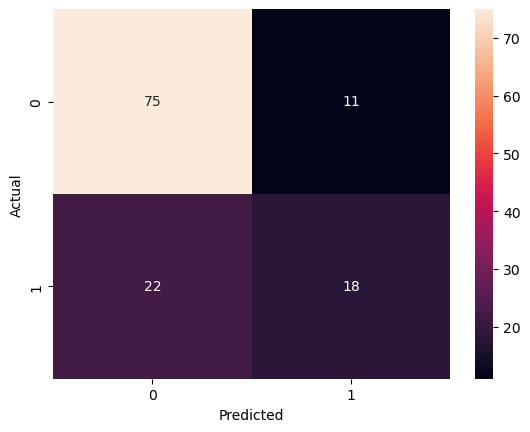

In [111]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [112]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:,1]

print("ROC AUC:", roc_auc_score(y_test, y_prob))

ROC AUC: 0.7947674418604651


In [113]:
y.value_counts()

Outcome
0    438
1    192
Name: count, dtype: int64

In [ ]:
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

In [115]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7380952380952381


In [116]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Precision: 0.6206896551724138
Recall: 0.45
F1 Score: 0.5217391304347826


In [117]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[75 11]
 [22 18]]


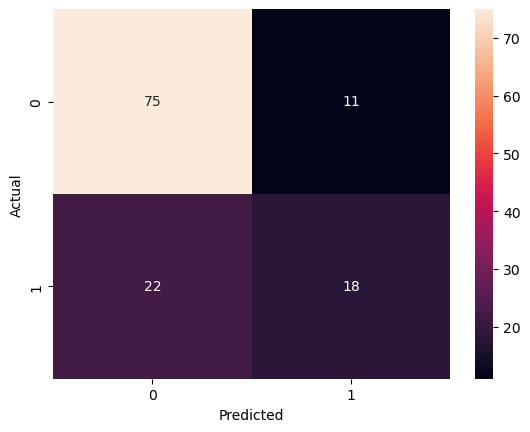

In [118]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [119]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [120]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("KNN F1:", f1_score(y_test, y_pred_knn))

KNN Accuracy: 0.7142857142857143
KNN F1: 0.5


In [121]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)  # scaling ki zarurat nahi

y_pred_dt = dt.predict(X_test)

print("DT Accuracy:", accuracy_score(y_test, y_pred_dt))
print("DT F1:", f1_score(y_test, y_pred_dt))

DT Accuracy: 0.7301587301587301
DT F1: 0.5952380952380952


In [122]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)  # scaling ki zarurat nahi

y_pred_rf = rf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print("RF F1:", f1_score(y_test, y_pred_rf))

RF Accuracy: 0.746031746031746
RF F1: 0.5294117647058824


In [125]:
from sklearn.metrics import roc_auc_score

print("LR ROC:", roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:,1]))
print("RF ROC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))
print("KNN ROC:", roc_auc_score(y_test, knn.predict_proba(X_test_scaled)[:,1]))

LR ROC: 0.7947674418604651
RF ROC: 0.7638081395348837
KNN ROC: 0.703343023255814


In [127]:
print(
    "DT ROC:",
    roc_auc_score(
        y_test,
        dt.predict_proba(X_test)[:,1]
    )
)

DT ROC: 0.7020348837209303


In [128]:
results = pd.DataFrame({
    "Model":["Logistic Regression","KNN","Decision Tree","Random Forest"],
    "Accuracy":[0.738,0.714,0.730,0.746],
    "F1":[0.522,0.500,0.595,0.529],
    "ROC-AUC":[0.795,0.703,None,0.764]
})

results

,Model,Accuracy,F1,ROC-AUC
0,Logistic Regression,0.738,0.522,0.795
1,KNN,0.714,0.500,0.703
2,Decision Tree,0.730,0.595,NaN
3,Random Forest,0.746,0.529,0.764


In [129]:
import pickle

pickle.dump(model, open("diabetes_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))